# Q1

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms

In [50]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

x1=unpickle("/content/data_batch_1")
x2=unpickle("/content/data_batch_2")
x3=unpickle("/content/data_batch_3")
x4=unpickle("/content/data_batch_4")
x5=unpickle("/content/data_batch_5")
x6=unpickle("/content/test_batch")

label1 = x1[b'labels']
data1 = x1[b'data']

label2 = x2[b'labels']
data2 = x2[b'data']

label3 = x3[b'labels']
data3 = x3[b'data']

label4 = x4[b'labels']
data4 = x4[b'data']

label5 = x5[b'labels']
data5 = x5[b'data']

label6 = x6[b'labels']
data6 = x6[b'data']

In [51]:
# Data
Data=[]

for i in range(len(data1)):
  x = data1[i].reshape(3,32,32)
  Data.append(x)

for i in range(len(data2)):
  x = data2[i].reshape(3,32,32)
  Data.append(x)

for i in range(len(data3)):
  x = data3[i].reshape(3,32,32)
  Data.append(x)

for i in range(len(data4)):
  x = data4[i].reshape(3,32,32)
  Data.append(x)

for i in range(len(data5)):
  x = data5[i].reshape(3,32,32)
  Data.append(x)

for i in range(len(data6)):
  x = data6[i].reshape(3,32,32)
  Data.append(x)

Data=np.array(Data)
print(Data.shape)

(60000, 3, 32, 32)


In [52]:
# labels

labels=label1+label2+label3+label4+label5+label6
labels=np.array(labels)
print(labels.shape)

(60000,)


In [53]:
Data=torch.from_numpy(Data)
labels=torch.from_numpy(labels)

In [6]:
Data=torch.tensor(Data, dtype=torch.float32)
labels=torch.tensor(labels, dtype=torch.int64)

<ipython-input-6-2b477889a734>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Data=torch.tensor(Data, dtype=torch.float32)
<ipython-input-6-2b477889a734>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels=torch.tensor(labels, dtype=torch.int64)


Split into train val test

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class CustomDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

dataset = CustomDataset(Data, labels)


train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    break

Batch of images shape: torch.Size([64, 3, 32, 32])
Batch of labels shape: torch.Size([64])


Alexnet

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
import torch
from torchsummary import summary

alexnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)


num_classes = 10
alexnet_model.classifier[1] = torch.nn.Linear(alexnet_model.classifier[1].in_features, 1024)
alexnet_model.classifier[4] = torch.nn.Linear(1024,512)
alexnet_model.classifier[6] = torch.nn.Linear(512, num_classes)
alexnet_model.features[0]=torch.nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

alexnet_model = alexnet_model.to(device)

summary(alexnet_model, input_size=(3, 32, 32), device=str(device))

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 15, 15]               0
            Conv2d-4          [-1, 192, 15, 15]         307,392
              ReLU-5          [-1, 192, 15, 15]               0
         MaxPool2d-6            [-1, 192, 7, 7]               0
            Conv2d-7            [-1, 384, 7, 7]         663,936
              ReLU-8            [-1, 384, 7, 7]               0
            Conv2d-9            [-1, 256, 7, 7]         884,992
             ReLU-10            [-1, 256, 7, 7]               0
           Conv2d-11            [-1, 256, 7, 7]         590,080
             ReLU-12            [-1, 256, 7, 7]               0
        MaxPool2d-13            [-1, 256, 3, 3]               0
AdaptiveAvgPool2d-14            [-1, 25

resnet50

In [12]:
from torchvision.models import resnet50
from torchsummary import summary

resnet50_model = resnet50(pretrained=False, num_classes=10)

resnet50_model = resnet50_model.to(device)

summary(resnet50_model, input_size=(3, 32, 32), device=str(device))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 16, 16]           9,408
       BatchNorm2d-2           [-1, 64, 16, 16]             128
              ReLU-3           [-1, 64, 16, 16]               0
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]           4,096
       BatchNorm2d-6             [-1, 64, 8, 8]             128
              ReLU-7             [-1, 64, 8, 8]               0
            Conv2d-8             [-1, 64, 8, 8]          36,864
       BatchNorm2d-9             [-1, 64, 8, 8]             128
             ReLU-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]          16,384
      BatchNorm2d-12            [-1, 256, 8, 8]             512
           Conv2d-13            [-1, 256, 8, 8]          16,384
      BatchNorm2d-14            [-1, 25

In [13]:
import torch.nn as nn
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer_alexnet = optim.Adam(alexnet_model.parameters(), lr=0.01)
optimizer_resnet50 = optim.Adam(resnet50_model.parameters(), lr=0.01)

In [14]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:

Train_loss=[]
Val_loss=[]
Train_acc=[]
Val_acc=[]

epochs=50

early_stopping = EarlyStopping()

for epoch in range(epochs):
        print(f"epoch : {epoch+1}")

        alexnet_model.train()
        train_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = alexnet_model(inputs)
            loss = loss_fn(outputs, targets)

            optimizer_alexnet.zero_grad()
            loss.backward()
            optimizer_alexnet.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_acc = 100. * correct / total
        train_loss /= len(train_loader)
        Train_loss.append(train_loss)
        Train_acc.append(train_acc)


        alexnet_model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = alexnet_model(inputs)
                loss = loss_fn(outputs, targets)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_acc = 100. * correct / total
        val_loss /= len(val_loader)

        Val_loss.append(val_loss)
        Val_acc.append(val_acc)

        if early_stopping(val_loss):
          print(f"Training halted at epoch {epoch + 1}")
          break

        print(f"Train loss : {train_loss} train_acc : {train_acc}  val loss :{val_loss} val_acc : {val_acc}")


epoch : 1
Train loss : 3079.504902355203 train_acc : 9.647619047619047  val loss :2.3035785441702985 val_acc : 9.3
epoch : 2
Train loss : 2.3036631714082016 train_acc : 9.964285714285714  val loss :2.3036840494642865 val_acc : 9.366666666666667
epoch : 3
Train loss : 2.3037349430211966 train_acc : 9.91904761904762  val loss :2.306066135142712 val_acc : 9.3
epoch : 4
Train loss : 2.3037747527547805 train_acc : 10.071428571428571  val loss :2.3028662001833005 val_acc : 9.916666666666666
epoch : 5
Train loss : 2.3036474684420605 train_acc : 10.138095238095238  val loss :2.3037129057214614 val_acc : 9.366666666666667
epoch : 6
Training halted at epoch 6


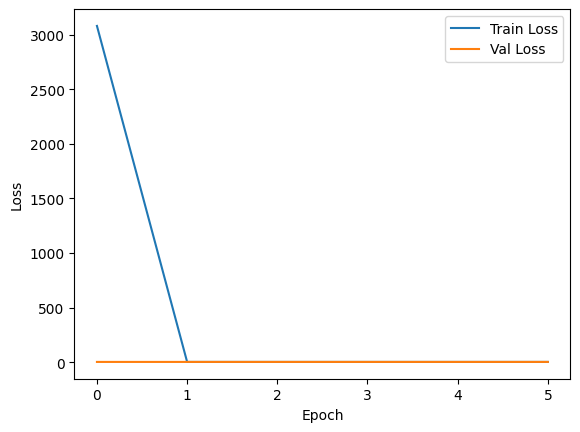

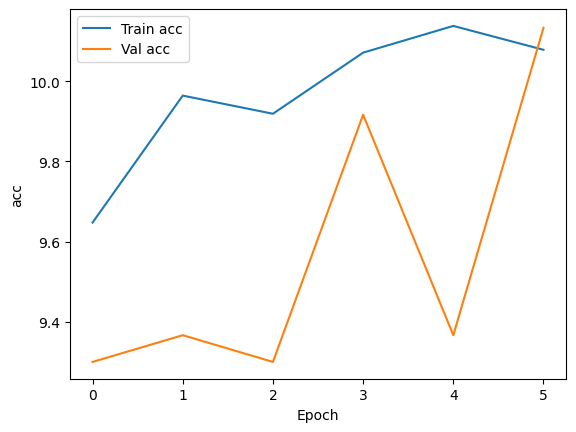

In [17]:
plt.plot(Train_loss, label='Train Loss')
plt.plot(Val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(Train_acc, label='Train acc')
plt.plot(Val_acc, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('acc')
plt.legend()
plt.show()

In [19]:
test_loss, correct, total = 0, 0, 0
with torch.no_grad():
  for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = alexnet_model(inputs)
    loss = loss_fn(outputs, targets)

    test_loss += loss.item()
    _, predicted = outputs.max(1)
    total += targets.size(0)
    correct += predicted.eq(targets).sum().item()

  test_acc = 100. * correct / total
  test_loss /= len(test_loader)

print("Testing loss :",test_loss)
print("Testing accuracy :",test_acc)

Testing loss : 2.3041052272979248
Testing accuracy : 9.925


In [20]:

Train_loss=[]
Val_loss=[]
Train_acc=[]
Val_acc=[]

epochs=50

early_stopping = EarlyStopping()

for epoch in range(epochs):
        print(f"epoch : {epoch+1}")

        resnet50_model.train()
        train_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = resnet50_model(inputs)
            loss = loss_fn(outputs, targets)

            optimizer_resnet50.zero_grad()
            loss.backward()
            optimizer_resnet50.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_acc = 100. * correct / total
        train_loss /= len(train_loader)
        Train_loss.append(train_loss)
        Train_acc.append(train_acc)


        resnet50_model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = resnet50_model(inputs)
                loss = loss_fn(outputs, targets)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_acc = 100. * correct / total
        val_loss /= len(val_loader)

        Val_loss.append(val_loss)
        Val_acc.append(val_acc)

        if early_stopping(val_loss):
          print(f"Training halted at epoch {epoch + 1}")
          break

        print(f"Train loss : {train_loss} train_acc : {train_acc}  val loss :{val_loss} val_acc : {val_acc}")


epoch : 1
Train loss : 2.5092113246656442 train_acc : 24.3  val loss :1.7420821823972337 val_acc : 36.96666666666667
epoch : 2
Train loss : 1.599562956317919 train_acc : 40.94047619047619  val loss :1.6796352191174284 val_acc : 40.766666666666666
epoch : 3
Train loss : 1.4648141772961145 train_acc : 46.95238095238095  val loss :1.546498864255053 val_acc : 44.86666666666667
epoch : 4
Train loss : 1.348707579586604 train_acc : 51.364285714285714  val loss :1.3750233574116484 val_acc : 52.53333333333333
epoch : 5
Train loss : 1.2575196609286594 train_acc : 54.84047619047619  val loss :2.2911099588617367 val_acc : 45.35
epoch : 6
Train loss : 1.2936255180672422 train_acc : 54.054761904761904  val loss :1.4668684779329504 val_acc : 48.2
epoch : 7
Train loss : 1.1587230862547817 train_acc : 58.99285714285714  val loss :1.2343636928720678 val_acc : 56.483333333333334
epoch : 8
Train loss : 1.2004617045277692 train_acc : 57.864285714285714  val loss :1.434479092029815 val_acc : 51.783333333333

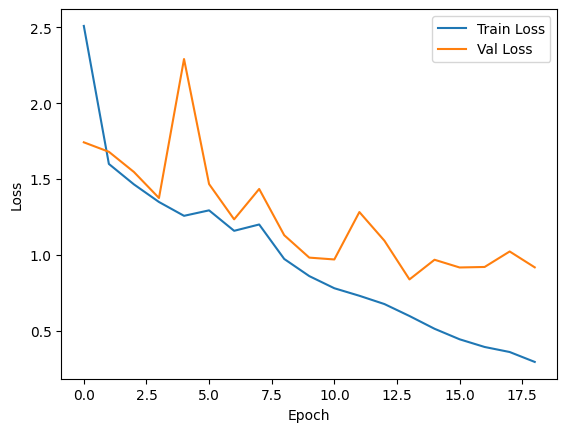

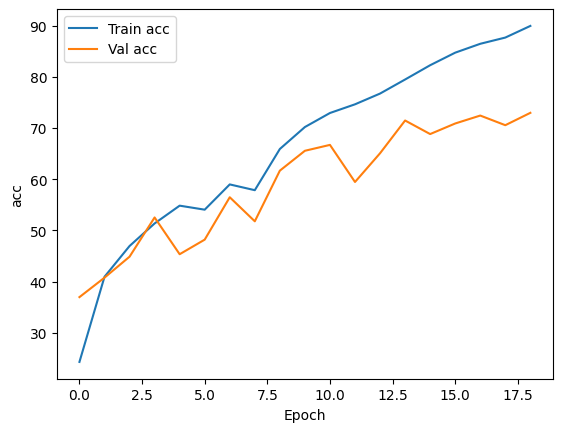

In [21]:
plt.plot(Train_loss, label='Train Loss')
plt.plot(Val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(Train_acc, label='Train acc')
plt.plot(Val_acc, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('acc')
plt.legend()
plt.show()

In [22]:
test_loss, correct, total = 0, 0, 0
with torch.no_grad():
  for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = resnet50_model(inputs)
    loss = loss_fn(outputs, targets)

    test_loss += loss.item()
    _, predicted = outputs.max(1)
    total += targets.size(0)
    correct += predicted.eq(targets).sum().item()

  test_acc = 100. * correct / total
  test_loss /= len(test_loader)

print("Testing loss :",test_loss)
print("Testing accuracy :",test_acc)

Testing loss : 0.9412942023036328
Testing accuracy : 72.81666666666666


**Observation**

**(c)**

1.Accuracy of Alexnet model 9.925%

2.Accuracy of resnet50 model is 72.81%

**(e)**

Perfermance conparison

1.Alexnet model
accuracy=9.925%
epoch=6
parameter=12,416,330

2.resnet50 model
accuracy=72.81%
epoch=18
parameter=23,528,522   

On the basis of these i will select resnet50 model for evaluation

# Q2

(a)

In [1]:
from io import open
import glob
import os

def findFiles(path): return glob.glob(path)

print(findFiles('/content/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)


def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

category_lines = {}
all_categories = []

def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('/content/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

['/content/English.txt', '/content/Russian.txt', '/content/Arabic.txt', '/content/Vietnamese.txt', '/content/Greek.txt', '/content/Korean.txt', '/content/French.txt', '/content/Dutch.txt', '/content/Spanish.txt', '/content/Portuguese.txt', '/content/Chinese.txt', '/content/Irish.txt', '/content/Polish.txt', '/content/Japanese.txt', '/content/Italian.txt', '/content/Scottish.txt', '/content/German.txt', '/content/Czech.txt']
Slusarski


In [2]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


In [3]:
import torch

def letterToIndex(letter):
    return all_letters.find(letter)

def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

In [5]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.9545, -2.8468, -2.9359, -2.9462, -2.7999, -2.8480, -2.9725, -2.9494,
         -2.7674, -2.9532, -2.8846, -2.8133, -2.9292, -3.0005, -2.8895, -2.7682,
         -2.9251, -2.8860]], grad_fn=<LogSoftmaxBackward0>)


In [6]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('Spanish', 8)


In [7]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Spanish / line = Lobo
category = Arabic / line = Bishara
category = Chinese / line = Thien
category = Scottish / line = Docherty
category = Spanish / line = Quintana
category = Vietnamese / line = Quang
category = Vietnamese / line = Nghiem
category = Portuguese / line = Santiago
category = Vietnamese / line = Chu
category = Portuguese / line = Abreu


In [8]:
criterion = nn.NLLLoss()

In [9]:
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()

    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [10]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 10s) 0.5552 Frangopoulos / Greek ✓
10000 10% (0m 21s) 1.9529 Rypka / Japanese ✗ (Czech)
15000 15% (0m 31s) 1.8814 Molloy / Scottish ✗ (Irish)
20000 20% (0m 43s) 2.4306 Fernandes / Dutch ✗ (Portuguese)
25000 25% (0m 55s) 0.3954 Koo / Korean ✓
30000 30% (1m 6s) 0.0776 Kozlowski / Polish ✓
35000 35% (1m 16s) 2.9302 Vlach / Irish ✗ (Czech)
40000 40% (1m 26s) 0.5354 Nassar / Arabic ✓
45000 45% (1m 36s) 0.1243 Antar / Arabic ✓
50000 50% (1m 47s) 0.0874 Papoutsis / Greek ✓
55000 55% (1m 57s) 1.0645 Schindler / German ✓
60000 60% (2m 8s) 0.3918 Amari / Arabic ✓
65000 65% (2m 19s) 0.6114 Shige / Japanese ✓
70000 70% (2m 31s) 2.9925 Gallchobhar / German ✗ (Irish)
75000 75% (2m 44s) 1.5003 Chao / Vietnamese ✗ (Chinese)
80000 80% (2m 53s) 0.1040 Quan / Chinese ✓
85000 85% (3m 4s) 0.0975 Arian / Arabic ✓
90000 90% (3m 14s) 3.0995 Kay / Vietnamese ✗ (English)
95000 95% (3m 25s) 0.0390 Romeijnsen / Dutch ✓
100000 100% (3m 35s) 2.3131 Serafin / Russian ✗ (Polish)


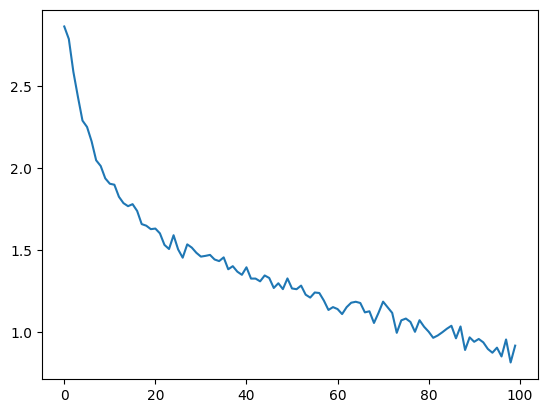

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

<ipython-input-12-ad3198427f7e>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
<ipython-input-12-ad3198427f7e>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


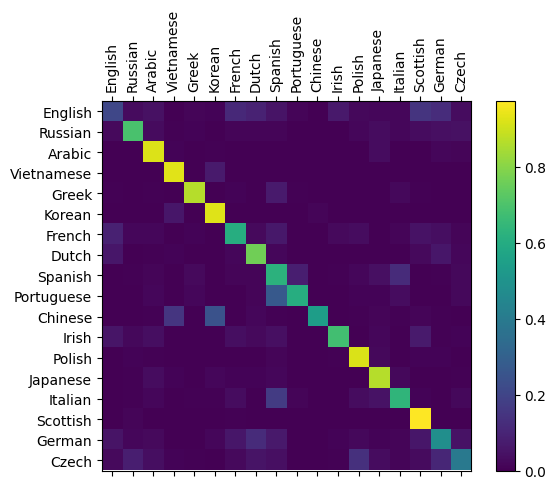

In [12]:
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

In [13]:
correct_predictions = confusion.diagonal().sum().item()
total_samples = confusion.sum().item()

accuracy = correct_predictions / total_samples * 100
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 70.24%


(b)

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GRU_model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU_model, self).__init__()
        self.hidden_size = hidden_size

        self.W_z = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_r = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), dim=1)

        z_t = torch.sigmoid(self.W_z(combined))
        r_t = torch.sigmoid(self.W_r(combined))

        combined_reset = torch.cat((input, r_t * hidden), dim=1)
        h_hat_t = torch.tanh(self.W_h(combined_reset))

        h_t = z_t * hidden + (1-z_t) * h_hat_t

        output = self.fc(h_t)
        output = self.softmax(output)

        return output, h_t

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)


n_letters = 57
n_hidden = 128
n_categories = 18

gru_model = GRU_model(n_letters, n_hidden, n_categories)

print(gru_model)


GRU_model(
  (W_z): Linear(in_features=185, out_features=128, bias=True)
  (W_r): Linear(in_features=185, out_features=128, bias=True)
  (W_h): Linear(in_features=185, out_features=128, bias=True)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [15]:
criterion = nn.NLLLoss()

In [16]:
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = gru_model.initHidden()

    gru_model.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = gru_model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    for p in gru_model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [17]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 23s) 2.7781 Murray / Japanese ✗ (Scottish)
10000 10% (0m 46s) 2.8217 Madeira / Japanese ✗ (Portuguese)
15000 15% (1m 11s) 2.4967 Shu / Chinese ✓
20000 20% (1m 40s) 1.6615 Behtenev / Russian ✓
25000 25% (2m 2s) 2.2809 Adashik / Polish ✗ (Russian)
30000 30% (2m 32s) 2.3428 Como / Korean ✗ (Italian)
35000 35% (2m 56s) 0.8168 Saionji / Japanese ✓
40000 40% (3m 25s) 2.0300 Santana / Spanish ✗ (Portuguese)
45000 45% (3m 48s) 0.4583 Takudo / Japanese ✓
50000 50% (4m 16s) 1.0169 Ma / Vietnamese ✓
55000 55% (4m 39s) 0.6594 Tadeshi / Japanese ✓
60000 60% (5m 2s) 0.0147 Vannikov / Russian ✓
65000 65% (5m 32s) 0.1973 Hiyama / Japanese ✓
70000 70% (5m 55s) 0.4004 Rigatos / Greek ✓
75000 75% (6m 22s) 1.1977 Tanuma / Arabic ✗ (Japanese)
80000 80% (6m 49s) 0.7917 Walter / German ✓
85000 85% (7m 15s) 1.2647 Gorka / Czech ✗ (Polish)
90000 90% (7m 41s) 2.0560 Reed / German ✗ (English)
95000 95% (8m 9s) 2.1583 Rizzo / Spanish ✗ (Italian)
100000 100% (8m 32s) 2.4839 Charron / Scottish ✗ (French

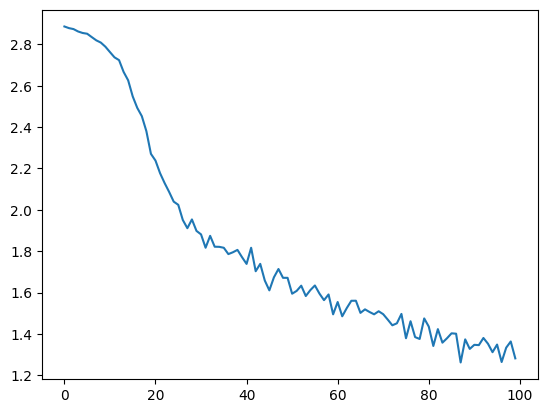

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

<ipython-input-19-ef063bba8049>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
<ipython-input-19-ef063bba8049>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


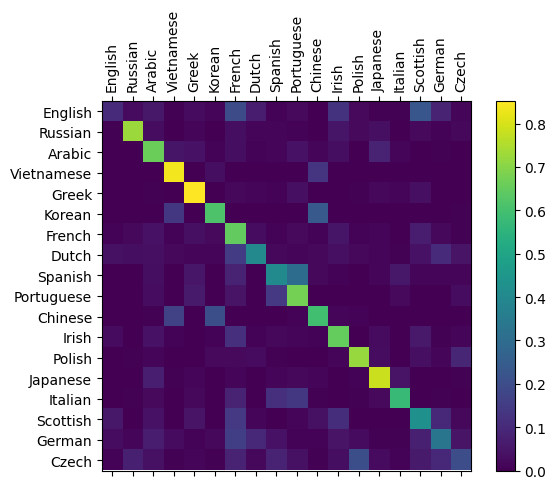

In [19]:
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line_tensor):
    hidden = gru_model.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = gru_model(line_tensor[i], hidden)

    return output

for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

In [20]:
correct_predictions = confusion.diagonal().sum().item()
total_samples = confusion.sum().item()

accuracy = correct_predictions / total_samples * 100
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 56.70%


(c)

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTM_model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM_model, self).__init__()
        self.hidden_size = hidden_size

        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        h_t, c_t = hidden

        combined = torch.cat((input, h_t), dim=1)

        i_t = torch.sigmoid(self.W_i(combined))
        f_t = torch.sigmoid(self.W_f(combined))
        o_t = torch.sigmoid(self.W_o(combined))
        c_hat_t = torch.tanh(self.W_c(combined))

        c_t = f_t * c_t + i_t * c_hat_t

        h_t = o_t * torch.tanh(c_t)

        output = self.fc(h_t)
        output = self.softmax(output)

        return output, (h_t, c_t)

    def initHidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))


n_letters = 57
n_hidden = 128
n_categories = 18

lstm_model = LSTM_model(n_letters, n_hidden, n_categories)

print(lstm_model)


LSTM_model(
  (W_i): Linear(in_features=185, out_features=128, bias=True)
  (W_f): Linear(in_features=185, out_features=128, bias=True)
  (W_c): Linear(in_features=185, out_features=128, bias=True)
  (W_o): Linear(in_features=185, out_features=128, bias=True)
  (fc): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [22]:
criterion = nn.NLLLoss()

In [23]:
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = lstm_model.initHidden()

    lstm_model.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = lstm_model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    for p in lstm_model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [24]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 28s) 2.9036 Tableriou / Irish ✗ (Greek)
10000 10% (0m 56s) 2.8473 Polson / French ✗ (English)
15000 15% (1m 24s) 2.9308 Hong / Chinese ✗ (Korean)
20000 20% (1m 53s) 2.7898 Coupe / French ✓
25000 25% (2m 22s) 2.7800 She / Chinese ✓
30000 30% (2m 48s) 2.6492 Janes / Greek ✗ (English)
35000 35% (3m 13s) 2.5804 Eoin / Chinese ✗ (Irish)
40000 40% (3m 38s) 2.6734 Turchi / Chinese ✗ (Italian)
45000 45% (4m 3s) 3.1199 Valtuh / Arabic ✗ (Russian)
50000 50% (4m 28s) 1.4920 Benini / Italian ✓
55000 55% (4m 53s) 1.8455 Cassidy / Russian ✗ (Irish)
60000 60% (5m 18s) 0.3979 Vyazankin / Russian ✓
65000 65% (5m 43s) 1.5428 Schwarzenberg / German ✗ (Dutch)
70000 70% (6m 8s) 1.7339 Gouveia / Spanish ✗ (Portuguese)
75000 75% (6m 33s) 1.1377 Kau / Vietnamese ✗ (Chinese)
80000 80% (6m 57s) 2.4135 Paul / Arabic ✗ (French)
85000 85% (7m 22s) 0.6226 Araujo / Portuguese ✓
90000 90% (7m 46s) 2.3281 Aonghus / English ✗ (Irish)
95000 95% (8m 12s) 2.7154 Watnabe / French ✗ (Japanese)
100000 100% (8m 36

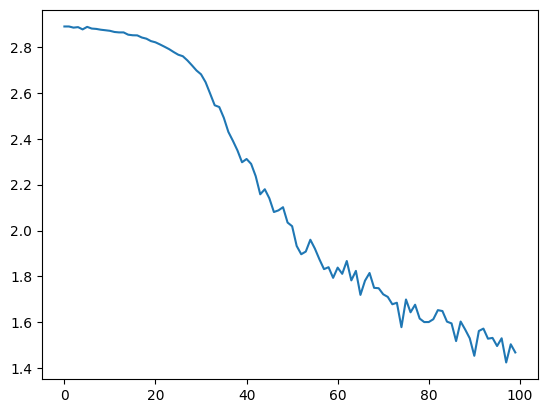

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

<ipython-input-26-4e71a406ad87>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
<ipython-input-26-4e71a406ad87>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


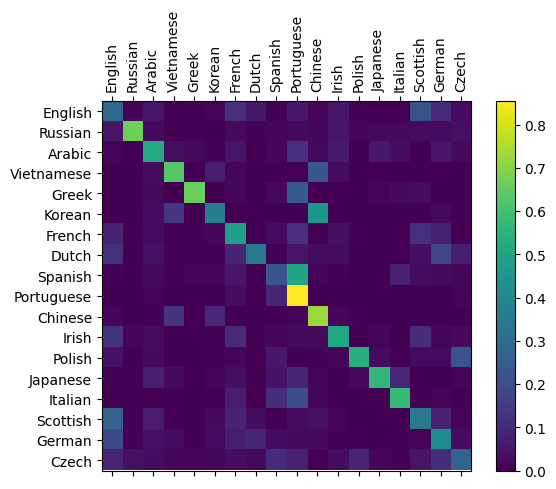

In [26]:
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line_tensor):
    hidden = lstm_model.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = lstm_model(line_tensor[i], hidden)

    return output

for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

In [27]:
correct_predictions = confusion.diagonal().sum().item()
total_samples = confusion.sum().item()

accuracy = correct_predictions / total_samples * 100
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 49.94%


**Observation**

1.Accuracy of gru model is 56.70%

2.Accuracy of lstm model is 49.94%